## Import Library Yang Dibutuhkan

In [2]:
#Library Web Scraping Gmaps
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import NoSuchElementException
from selenium.webdriver.support.ui import WebDriverWait
import time, pandas as pd


## Scraping RevieW Google Maps Pantai Labuhan Jukung, Lampung

In [ ]:
# Variable untuk agar review dengan Bahasa Indonesia
options = uc.ChromeOptions()
options.add_argument('--lang=id')
options.add_argument('--accept-language=id-ID,id')  
options.add_argument('--disable-blink-features=AutomationControlled')  
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')


driver = uc.Chrome(options=options)  

# Panggil lokasi digmaps lewat URL
driver.get("https://www.google.com/maps/place/Labuhan+Jukung+Krui+Lampung/@-5.1901779,103.9213373,15z/data=!4m8!3m7!1s0x2e4794d953e10d21:0xff5eeb33da649e64!8m2!3d-5.1901781!4d103.9316371!9m1!1b1!16s%2Fg%2F11cjk3bd0m?entry=ttu&g_ep=EgoyMDI2MDEwNy4wIKXMDSoKLDEwMDc5MjA3MUgBUAM%3D")
time.sleep(5)  

# Filter untuk cek apakah lokasi benar-benar ada
try:
    nama_tempat = driver.find_element(By.CSS_SELECTOR, "h1.DUwDvf").text.strip()
    print("Nama tempat:", nama_tempat)
except NoSuchElementException:
    nama_tempat = "unknown location"
    print("Nama tempat tidak ditemukan")

# Function klik tombol ulasan lainnya jika ada
try:
    more_reviews = WebDriverWait(driver, 15).until(  
        EC.element_to_be_clickable((By.XPATH, "//span[contains(text(), 'Ulasan lainnya') or contains(text(), 'More reviews')]/ancestor::button")))
    more_reviews.click()
    print("Klik tombol ulasan lainnya.")
    time.sleep(4)
except:
    print("Tidak ada tombol ulasan lainnya.")

# Scraping data di Gmaps
reviews, seen = [], set()
while len(reviews) < 500: # Ambil 500 Data
    elements = driver.find_elements(By.CSS_SELECTOR, 'div.jftiEf')
    print(f"Review elements terdeteksi: {len(elements)}")  

    for c in elements:
        user_el = c.find_elements(By.CLASS_NAME, 'd4r55')
        review_el = c.find_elements(By.CLASS_NAME, 'wiI7pd')
        rating_el = c.find_elements(By.CLASS_NAME, 'kvMYJc')

        # Function untuk melanjutkan scraping jika review kosong
        if not review_el or not review_el[0].text.strip():
            continue
        user = user_el[0].text if user_el else 'Unknown'
        review = review_el[0].text.strip()
        rating = rating_el[0].get_attribute('aria-label').split()[0] if rating_el else 'Unknown'
        if (user, review) not in seen:
            seen.add((user, review))
            reviews.append({
                'nama_tempat': nama_tempat,
                'user': user,
                'review': review,
                'rating': rating
            })


    # Function untuk Auto Scroll
    try:
        last_elem = driver.find_elements(By.CSS_SELECTOR, 'div.jftiEf')[-1]
        driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", last_elem)
    except:
        print("Scroll gagal")
        break
    time.sleep(3)  # 

# Menyimpan hasil dari scraping GMAPS
pd.DataFrame(reviews).to_csv("ulasan_pan.csv", index=False)
print(f"[INFO] {len(reviews)} review berhasil di eksport")
driver.quit

## Pre Processing Data

In [5]:
import pandas as pd
import re

# Panggil Dataset
df = pd.read_csv(r"C:\Users\ACER\Downloads\ulasan_pan.xls")
df

# Pre-processing
def preprocess(text):
    if pd.isna(text) or not isinstance(text, str): # Jika atribut data kosong isi dengan ""
        return ""
    
    text = text.lower()                          # Case Folding
    text = re.sub(r'[^a-z\s]', '', text)         # hapus angka, simbol, dan tanda baca 
    text = re.sub(r'\s+', ' ', text).strip()     # hapus spasi yang lebih dari satu kaliu
    
    # Stemming Bahasa Indonesia
    words = text.split()
    cleaned_words = []
    for word in words:
        if word.endswith(('nya', 'nyaa')):
            word = word[:-3]
        elif word.endswith(('ku', 'mu' 'kah', 'lah', 'an', 'in')):
            word = word[:-2]
        cleaned_words.append(word)
    
    return ' '.join(cleaned_words)

# Simpan hasil pre-processing pada kolom review ke kolom baru 
df['review_clean'] = df['review'].apply(preprocess)

## Pelabelan Kata

In [12]:
# Definisikan Stopword (Kata penghubung)
stopwords = {
    'dan', 'yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'dengan', 'itu', 'di', 'dari', 'ini', 
    'saya', 'kami', 'karena', 'karna', 'sudah', 'bisa', 'ada', 'juga', 'setelah', 'kurang', 
    'lebih', 'tidak', 'sangat', 'aja', 'sih', 'nih', 'lah', 'pun', 'kok', 'loh',
    'pantai', 'krui', 'lampung', 'tempat', 'kesini', 'disini', 'sini', 'nya'
    'yg', 'd', 'dyg', 'sy', 'tp', 'tpi', 'dgn', 'dg', 'utk', 'bgt', 
    'gak', 'gk', 'ga', 'klo', 'kalo', 'sdh', 'udh', 'udah', 'aja',
    'jg', 'juga', 'nya', 'ny', 'si', 'sih', 'nih', 'deh', 'dong',
    'dr', 'drpd', 'pd', 'spy', 'krn', 'karna', 'knp', 'hal', 'bisa',
    'ada', 'jadi', 'masih', 'sudah', 'sama', 'buat', 'kita', 'saja',
    'tapi', 'kalau', 'seperti', 'semua', 'lagi', 'banyak', 'satu'
}

# Definisikan kategori kata-kata yang termasuk positif atau negatif
# Kamus positif & negatif (bisa ditambah sesuai data pantai)
positif = [
    'ramah', 'baik', 'puas', 'bersih', 'cepat', 'bagus', 'membantu', 'nyaman',
    'mudah', 'indah', 'mantap', 'keren', 'rekomendasi', 'luar biasa',
    'sangat baik', 'puas sekali', 'bersih sekali', 'enak', 'mantul', 'jos', 'gacor', 'surfing', 'sunset', 'gratis',
    'mantapp', 'mantappp', 'mantab', 'mantai', 'mantapnya', 'indahnya', 'keren', 'asik', 'cantik', 'seru', 'asri',
]

negatif = [
    'lambat', 'kecewa', 'buruk', 'kotor', 'lama', 'mahal', 'kasar', 'antri',
    'sulit', 'kurang', 'mengganggu', 'jelek', 'rusak', 'sampah', 'pungli',
    'mengecewakan', 'tidak direkomendasikan', 'parah', 'kecewa berat', 'kebersihan', 'sampah', 'parkir',
    'sayang', 'kurang', 'rusak', 'kotor', 'mahal', 'pungli', 'kecewa', 'terawat', 'kurang', 'sampah'
]

def sentimen(text):
    score = 0
    words = text.split()
    for w in words:
        if w in positif:
            score += 1
        if w in negatif:
            score -= 1

    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

# pelabelan di data frame
df['sentimen'] = df['review_clean'].apply(sentimen)

## Visualisasi Sentimen Posiitif dan Negative

In [13]:
# Panggil Library Yang dibutuhkan
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import numpy as np
from gensim import corpora, models

In [14]:
# Penerapan LDA terhadap dataset
def get_lda_topics(text_list, num_topics=1, num_words=5):
    # Filter untuk hanya mengambil kata yang bukan stopword 
    tokens = [[word for word in t.split() if word not in stopwords and len(word) > 3] 
              for t in text_list]
    
    # Filter list kosong
    tokens = [t for t in tokens if len(t) > 0]
    
    if not tokens:
        return ["Data tidak mencukupi untuk ekstraksi topik"]

    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(text) for text in tokens]
    
    if not corpus:
        return ["Data tidak mencukupi"]
        
    #  LDA diterapkan pada token
    lda_model = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=20, random_state=42)
    
    res = []
    for i, topic in lda_model.show_topics(formatted=False, num_words=num_words):
        words = [word for word, prob in topic]
        res.append(f"Topik {i+1}: {', '.join(words)}")
    return res

# Menampilkan hasil
print("STATISTIK SENTIMEN")
print(df['sentimen'].value_counts())

pos_reviews = df[df['sentimen'] == 'Positif']['review_clean'].tolist()
neu_reviews = df[df['sentimen'] == 'Netral']['review_clean'].tolist()
neg_reviews = df[df['sentimen'] == 'Negatif']['review_clean'].tolist()

print("\nANALISIS TOPIK DOMINAN")
print("Positif:", get_lda_topics(pos_reviews, num_topics=1))
print("Netral :", get_lda_topics(neu_reviews, num_topics=1))
print("Negatif:", get_lda_topics(neg_reviews, num_topics=1))

STATISTIK SENTIMEN
sentimen
Positif    289
Netral     172
Negatif     57
Name: count, dtype: int64

ANALISIS TOPIK DOMINAN
Positif: ['Topik 1: bagus, indah, ombak, bersih, sunset']
Netral : ['Topik 1: wisata, ombak, jukung, labuh, bagus']
Negatif: ['Topik 1: sampah, sayang, terawat, kotor, bagus']


## Visualisasi WordCLoud

WORD CLOUD VISUALISASI SENTIMEN


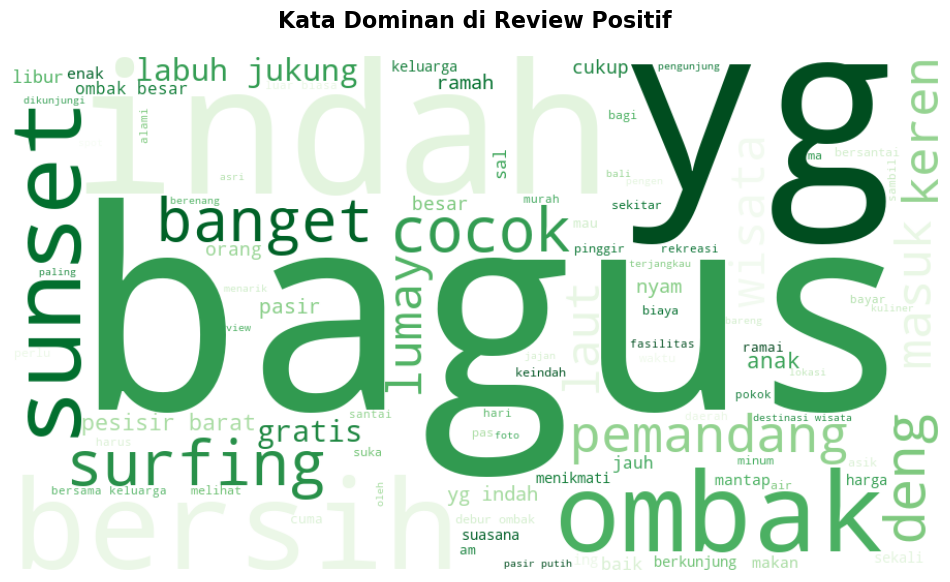

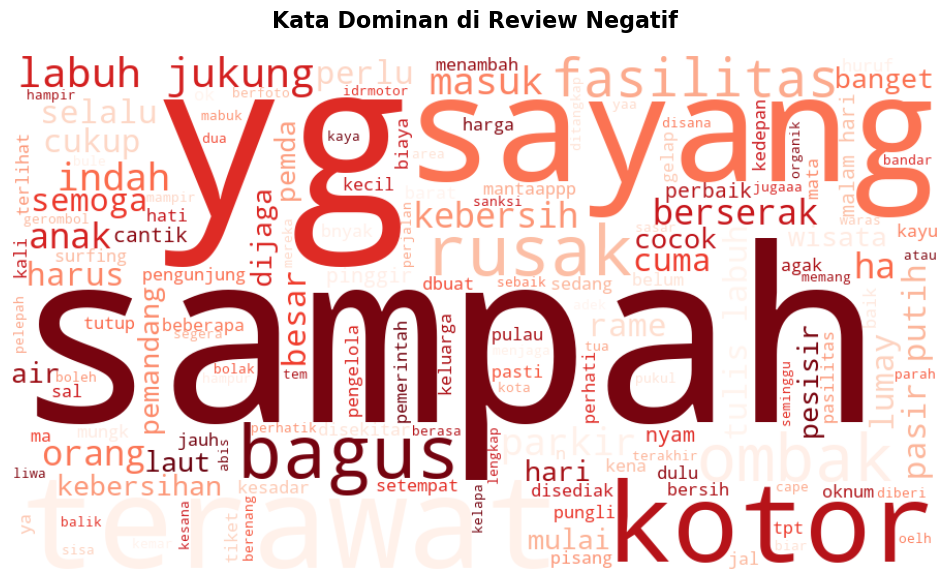

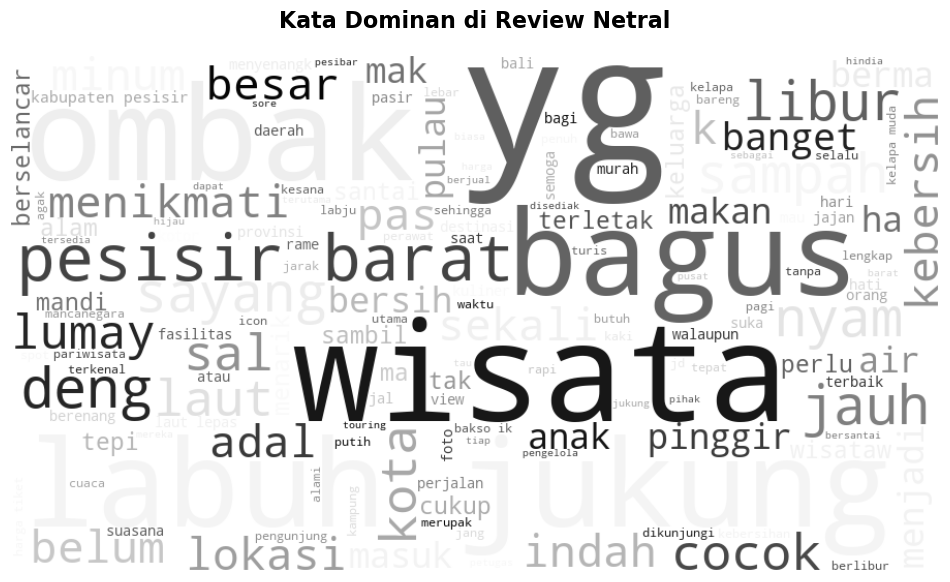

In [15]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan review berdasarkan sentimen
pos_reviews = df[df['sentimen'] == 'Positif']['review_clean'].tolist()
neg_reviews = df[df['sentimen'] == 'Negatif']['review_clean'].tolist()
neu_reviews = df[df['sentimen'] == 'Netral']['review_clean'].tolist()

# Fungsi untuk generate dan tampilkan Word Cloud
def show_wordcloud(text_list, title, colormap='viridis', figsize=(10, 6)):
    if not text_list:
        print(f"Tidak ada review untuk {title}")
        return
    
    # Gabung semua teks menjadi satu string
    text = ' '.join(text_list)
    
    # Buat Word Cloud
    wordcloud = WordCloud(
        width=900,
        height=500,
        background_color='white',
        colormap=colormap,           # warna sesuai sentimen
        min_font_size=10,
        max_words=150,
        contour_width=1,
        contour_color='steelblue',
        stopwords=stopwords          # pakai stopwords yang sudah kamu definisikan
    ).generate(text)
    
    # Tampilkan
    plt.figure(figsize=figsize)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.show()

# Tampilkan Word Cloud untuk masing-masing sentimen
print("WORD CLOUD VISUALISASI SENTIMEN")
show_wordcloud(pos_reviews, 'Kata Dominan di Review Positif', colormap='Greens', figsize=(12, 7))
show_wordcloud(neg_reviews, 'Kata Dominan di Review Negatif', colormap='Reds',   figsize=(12, 7))
show_wordcloud(neu_reviews, 'Kata Dominan di Review Netral',  colormap='Greys',  figsize=(12, 7))

